# M4 — Thompson Sampling e replay factual

Este notebook apresenta as evidências versionadas pelo pipeline `src.evaluation.replay`. Ele não reimplementa a política nem cria runs adicionais no MLflow.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Localiza a raiz mesmo quando o kernel inicia dentro de notebooks/.
project_root = Path.cwd().resolve()
if not (project_root / "configs").exists():
    project_root = project_root.parent
report_path = project_root / "reports/policy/m4_policy_evaluation.json"
assert report_path.exists(), "Execute python -m src.evaluation.replay antes do notebook."
report = json.loads(report_path.read_text(encoding="utf-8"))
report["selection"]

{'evaluation_splits': ['validation', 'test'],
 'gates_by_split': {'validation': True, 'test': True},
 'candidate_gate_passed': True,
 'status': 'candidate',
 'rollback_policy': 'best_historical_action',
 'interpretation': 'A política adaptativa só é candidata quando o lift médio e o limite inferior do intervalo são positivos.'}

## Comparação principal

A recompensa só é observada quando a recomendação coincide com o canal histórico. Por isso, recompensa e cobertura devem ser interpretadas juntas.

In [2]:
rows = []
for split_name in ["validation", "test"]:
    split = report["splits"][split_name]
    fixed = split["fixed_baseline"]
    adaptive = split["adaptive_policy"]
    rows.extend(
        [
            {
                "split": split_name,
                "policy": "baseline fixa",
                "mean_reward": fixed["mean_reward"],
                "coverage": fixed["replay_coverage"],
                "absolute_lift": 0.0,
            },
            {
                "split": split_name,
                "policy": "Thompson Sampling",
                "mean_reward": adaptive["mean_reward"]["mean"],
                "coverage": adaptive["replay_coverage"]["mean"],
                "absolute_lift": adaptive["lift_vs_fixed"]["absolute_mean"],
            },
        ]
    )
pd.DataFrame(rows)

,split,policy,mean_reward,coverage,absolute_lift
0,validation,baseline fixa,0.142966,0.635363,0.000000
1,validation,Thompson Sampling,0.172167,0.427844,0.029201
2,test,baseline fixa,0.151873,0.631051,0.000000
3,test,Thompson Sampling,0.179413,0.411068,0.027540


In [3]:
# Resume a dispersão das 30 seeds sem escolher uma execução favorável.
seed_results = pd.read_csv(project_root / "reports/policy/m4_seed_results.csv")
seed_results.groupby("split").agg(
    seeds=("seed", "nunique"),
    mean_reward=("mean_reward", "mean"),
    reward_std=("mean_reward", "std"),
    mean_coverage=("replay_coverage", "mean"),
    mean_lift=("absolute_lift_vs_fixed", "mean"),
)

,seeds,mean_reward,reward_std,mean_coverage,mean_lift
split,,,,,
test,30,0.179413,0.006444,0.411068,0.027540
validation,30,0.172167,0.005735,0.427844,0.029201


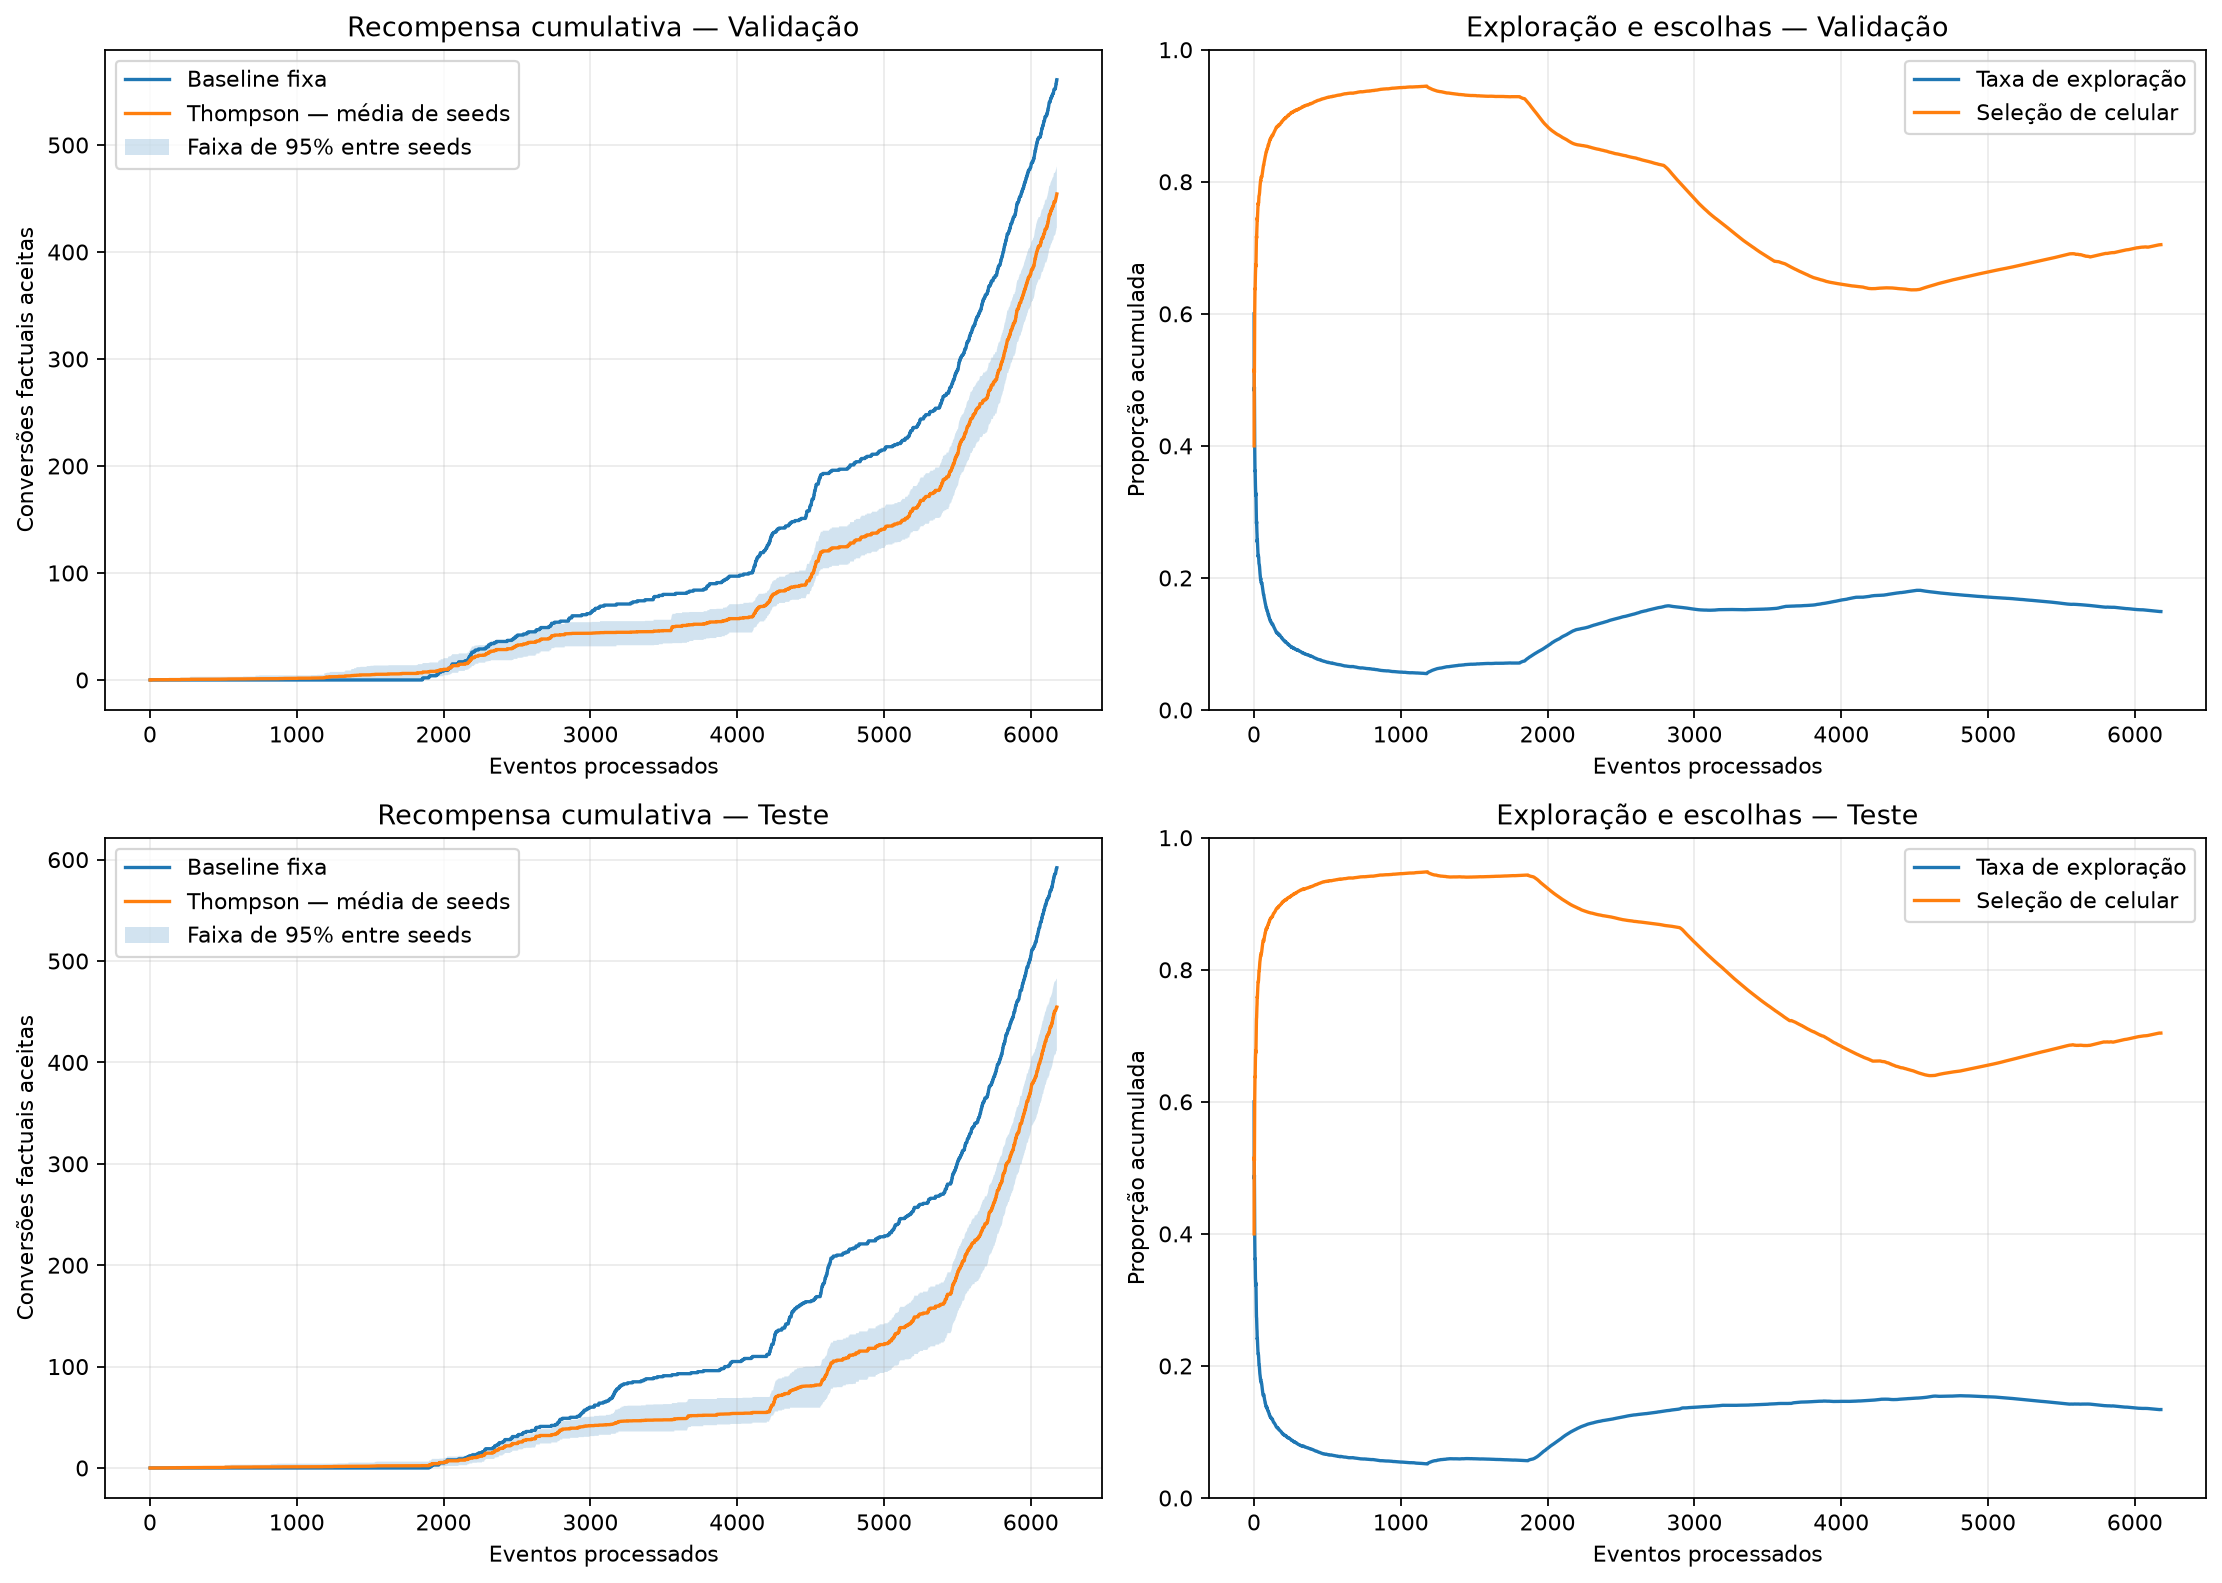

In [4]:
display(Image(filename=str(project_root / "reports/policy/m4_replay_comparison.png")))

## Conclusão responsável

O pequeno lift médio no teste não é suficiente para promoção: o intervalo de confiança inclui zero e a validação ficou abaixo do baseline. A política permanece rejeitada e o rollback continua sendo `best_historical_action`. O replay é evidência observacional, não uma estimativa causal de trocar o canal.